In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/text8-word-embedding/text8


Starting data preprocessing...
✅ Step 2: Checking index bounds...
Max index in encoded: 29999
Vocab size (len(word2idx)): 30000
Creating dataset...
Dataset created with 9999900 pairs.
Initializing model...
Actual vocab size used in model: 30000
Model initialized with 18000000 parameters.
Starting training...
CUDA Available: True
Using device: cuda
CUDA Version: 12.1
Number of GPUs: 2
GPU Name: Tesla T4
Initial GPU memory allocated: 0.00 MB
Initial GPU memory reserved: 0.00 MB


Epoch 1/10: 100%|██████████| 78125/78125 [08:18<00:00, 156.78batch/s, loss=27.9, Device=GPU (Tesla T4), GPU Mem=153.58 MB]


Epoch 1/10, Average Loss: 30.4648
GPU memory allocated after epoch 1: 84.92 MB
GPU memory reserved after epoch 1: 240.00 MB


Epoch 4/10: 100%|██████████| 78125/78125 [08:18<00:00, 156.81batch/s, loss=24.1, Device=GPU (Tesla T4), GPU Mem=153.58 MB]


Epoch 4/10, Average Loss: 20.7170
GPU memory allocated after epoch 4: 84.92 MB
GPU memory reserved after epoch 4: 240.00 MB


Epoch 5/10: 100%|██████████| 78125/78125 [08:18<00:00, 156.87batch/s, loss=13.4, Device=GPU (Tesla T4), GPU Mem=153.58 MB]


Epoch 5/10, Average Loss: 19.5809
GPU memory allocated after epoch 5: 84.92 MB
GPU memory reserved after epoch 5: 240.00 MB


Epoch 10/10: 100%|██████████| 78125/78125 [08:14<00:00, 157.92batch/s, loss=14.9, Device=GPU (Tesla T4), GPU Mem=153.58 MB]


Epoch 10/10, Average Loss: 16.9935
GPU memory allocated after epoch 10: 84.92 MB
GPU memory reserved after epoch 10: 240.00 MB


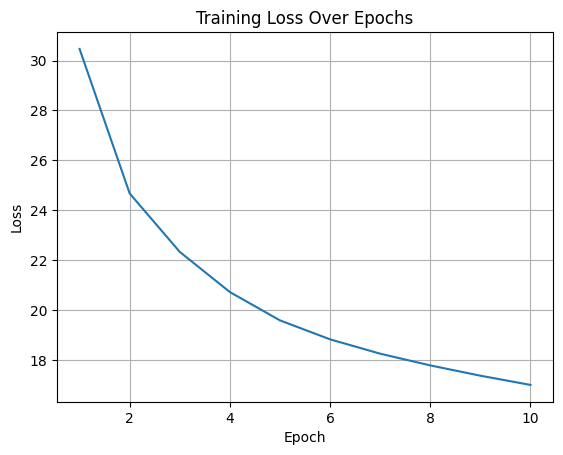

Final GPU memory allocated: 84.92 MB
Final GPU memory reserved: 94.00 MB
Visualizing embeddings...


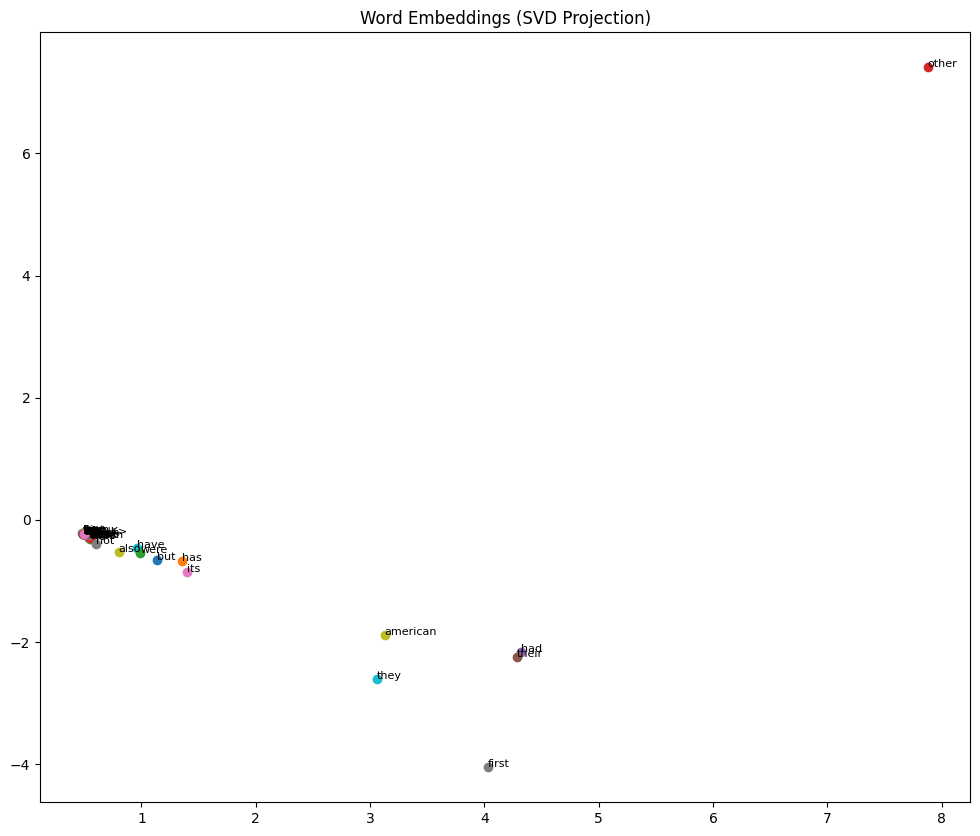

Performing analogy test...
Analogy Example (king - man + woman ≈ ?):
['bat', 'confession', 'notions', 'excelsus', 'urinal']
Cleanup completed. Program finished.


In [ ]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
from tqdm import tqdm  # For progress bar

# -------------------- 1. DATA PREPROCESSING --------------------

class Text8Dataset(Dataset):
    def __init__(self, text, word2idx, idx2word, window_size=5, num_negative=5):
        self.text = text
        self.window_size = window_size
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.vocab_size = len(word2idx)
        self.num_negative = num_negative

        # Precompute pairs for efficiency but with improved memory handling
        self.pairs = []
        for i in range(window_size, len(text) - window_size):
            center = text[i]
            # Use a symmetric window (excluding the center)
            context = text[i - window_size:i] + text[i + 1:i + window_size + 1]
            for target in context:
                self.pairs.append((center, target))

        # Precompute frequency distribution for negative sampling
        word_counts = Counter(text)
        self.word_freq = np.array([word_counts.get(i, 0) for i in range(self.vocab_size)], dtype=np.float32)
        self.word_freq = np.power(self.word_freq, 0.75)  # Apply subsampling exponent
        self.word_freq = self.word_freq / np.sum(self.word_freq)

        # Pre-generate negative samples in batches to improve efficiency
        self.negative_samples = np.random.choice(
            range(self.vocab_size),
            size=(len(self.pairs), num_negative),
            p=self.word_freq
        )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center, context = self.pairs[idx]
        negatives = self.negative_samples[idx]

        return (
        torch.LongTensor([center]),
        torch.LongTensor([context]),
        torch.clamp(torch.LongTensor(negatives), max=self.vocab_size - 1)
        )

def preprocess_text8(file_path, vocab_size=15000, max_words=500000):
    with open(file_path, 'r') as f:
        text = f.read().lower()
        text = re.sub(r'[^a-z ]+', '', text)
        words = text.split()
    if max_words is not None:
        words = words[:max_words]
    word_freq = Counter(words)
    most_common = word_freq.most_common(vocab_size - 1)
    # Build vocabulary with most common words and reserve index 0 for <UNK>
    vocab = {word: i + 1 for i, (word, _) in enumerate(most_common)}
    vocab['<UNK>'] = 0
    encoded = [vocab.get(word, 0) for word in words]
    idx2word = {i: word for word, i in vocab.items()}
    return encoded, vocab, idx2word

# -------------------- 2. MODEL --------------------

class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegSampling, self).__init__()
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center, context, negatives):
        center_emb = self.in_embed(center).squeeze(1)
        context_emb = self.out_embed(context).squeeze(1)
        neg_emb = self.out_embed(negatives)

        pos_score = torch.sum(center_emb * context_emb, dim=1)
        pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-9)

        neg_score = torch.bmm(neg_emb, center_emb.unsqueeze(2)).squeeze(2)
        neg_loss = -torch.sum(torch.log(1 - torch.sigmoid(neg_score) + 1e-9), dim=1)

        return torch.mean(pos_loss + neg_loss)

# -------------------- 3. TRAINING WITH STATUS TRACKING --------------------

def train_model(dataset, model, epochs=5, batch_size=64, lr=0.025, accumulation_steps=2):
    # Check CUDA availability and set device accordingly
    cuda_available = torch.cuda.is_available()
    device = torch.device('cuda' if cuda_available else 'cpu')
    print(f"CUDA Available: {cuda_available}")
    print(f"Using device: {device}")
    if cuda_available:
        print(f"CUDA Version: {torch.version.cuda}")
        print(f"Number of GPUs: {torch.cuda.device_count()}")
        print(f"GPU Name: {torch.cuda.get_device_name(0)}")
        print(f"Initial GPU memory allocated: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
        print(f"Initial GPU memory reserved: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")
    else:
        print("Warning: No CUDA-enabled GPU detected. Running on CPU.")

    model = model.to(device)
    # Add num_workers for parallel data loading
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=cuda_available, num_workers=4)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * len(loader) * accumulation_steps)
    loss_list = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        optimizer.zero_grad()
        progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")

        for i, (center, context, negatives) in enumerate(progress_bar):
            # Ensure tensors are on the correct device
            center, context, negatives = center.to(device), context.to(device), negatives.to(device)

            # Forward pass
            loss = model(center, context, negatives) / accumulation_steps

            # Backward pass
            loss.backward()

            # Gradient accumulation and optimization step
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
                scheduler.step()

            total_loss += loss.item() * accumulation_steps

            # Update progress bar with current status
            device_info = "CPU" if device.type == 'cpu' else f"GPU ({torch.cuda.get_device_name(0)})"
            if cuda_available:
                mem_allocated = torch.cuda.memory_allocated(device) / 1024**2
                progress_bar.set_postfix({'loss': loss.item() * accumulation_steps, 'Device': device_info, 'GPU Mem': f'{mem_allocated:.2f} MB'})
            else:
                progress_bar.set_postfix({'loss': loss.item() * accumulation_steps, 'Device': device_info})

        # Perform final optimization step if needed
        if len(loader) % accumulation_steps != 0:
            optimizer.step()
            optimizer.zero_grad()

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")
        loss_list.append(avg_loss)

        if cuda_available:
            print(f"GPU memory allocated after epoch {epoch+1}: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
            print(f"GPU memory reserved after epoch {epoch+1}: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")
            # Clear cache between epochs
            torch.cuda.empty_cache()

    plt.plot(range(1, epochs + 1), loss_list)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Over Epochs")
    plt.grid(True)
    plt.show()

    if cuda_available:
        torch.cuda.empty_cache()
        print(f"Final GPU memory allocated: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
        print(f"Final GPU memory reserved: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")
    else:
        print("No GPU used; all operations ran on CPU.")

    return model

# -------------------- 4. EVALUATION --------------------

def visualize_embeddings(model, idx2word, num_points=50):
    weights = model.in_embed.weight.data.cpu().numpy()
    svd = TruncatedSVD(n_components=2)
    reduced = svd.fit_transform(weights[:num_points])
    plt.figure(figsize=(12, 10))
    for i in range(num_points):
        plt.scatter(reduced[i, 0], reduced[i, 1])
        plt.annotate(idx2word[i], (reduced[i, 0], reduced[i, 1]), fontsize=8)
    plt.title("Word Embeddings (SVD Projection)")
    plt.show()

def analogy(model, word2idx, idx2word, w1, w2, w3, top_n=5, show_scores=False):
    def get_vec(w):
        return model.in_embed.weight[word2idx.get(w, 0)].detach().cpu().numpy()

    vec = get_vec(w1) - get_vec(w2) + get_vec(w3)
    all_weights = model.in_embed.weight.detach().cpu().numpy()
    sim = np.dot(all_weights, vec)

    exclude = set([word2idx.get(w1, 0), word2idx.get(w2, 0), word2idx.get(w3, 0)])

    top_idx = []
    for i in np.argsort(-sim):
        if i not in exclude:
            top_idx.append(i)
        if len(top_idx) == top_n:
            break

    if show_scores:
        print("Top similar words with similarity scores:")
        for i in top_idx:
            print(f"{idx2word[i]}: {sim[i]:.4f}")

    return [idx2word[i] for i in top_idx]

# -------------------- 5. RUNNING EVERYTHING WITH STATUS TRACKING --------------------

if __name__ == "__main__":
    text8_path = "/kaggle/input/text8-word-embedding/text8"
    try:
        print("Starting data preprocessing...")
      #  encoded, word2idx, idx2word = preprocess_text8(text8_path, vocab_size=15000, max_words=500000)
        encoded, word2idx, idx2word = preprocess_text8(text8_path, vocab_size=30000, max_words=1000000)
        print("✅ Step 2: Checking index bounds...")
        print("Max index in encoded:", max(encoded))
        print("Vocab size (len(word2idx)):", len(word2idx))
        assert max(encoded) < len(word2idx), "❌ ERROR: Index out of bounds of vocab size!"

        print("Creating dataset...")
        dataset = Text8Dataset(encoded, word2idx, idx2word, window_size=5, num_negative=5)
        print(f"Dataset created with {len(dataset)} pairs.")

        print("Initializing model...")
        #model = SkipGramNegSampling(vocab_size=len(word2idx), embedding_dim=300)
        vocab_size = len(word2idx)  # <-- NEW LINE
        model = SkipGramNegSampling(vocab_size=vocab_size, embedding_dim=300)

        print(f"Actual vocab size used in model: {len(word2idx)}")

       # model = SkipGramNegSampling(vocab_size=15000, embedding_dim=300)
        print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters.")

        print("Starting training...")
        # Increase batch size for better GPU utilization
        #trained_model = train_model(dataset, model, epochs=5, batch_size=128, lr=0.025, accumulation_steps=2)
        trained_model = train_model(dataset, model, epochs=10, batch_size=128, lr=0.025, accumulation_steps=2)

        print("Visualizing embeddings...")
        visualize_embeddings(trained_model, idx2word, num_points=50)

        print("Performing analogy test...")
        print("Analogy Example (king - man + woman ≈ ?):")
        result = analogy(trained_model, word2idx, idx2word, "king", "man", "woman")
        print(result)

    except FileNotFoundError:
        print(f"Error: File {text8_path} not found. Please check the path.")
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    finally:
        print("Cleanup completed. Program finished.")

In [ ]:
# === Save model after training completes ===
torch.save(model.state_dict(), "skipgram_model_final.pt")
print("✅ Model saved as skipgram_model_final.pt")

# Save vocabulary mappings
import pickle
with open("vocab_final.pkl", "wb") as f:
    pickle.dump((word2idx, idx2word), f)
print("✅ Vocabulary saved as vocab_final.pkl")


✅ Model saved as skipgram_model_final.pt
✅ Vocabulary saved as vocab_final.pkl


In [ ]:
import os
print("Current working directory:", os.getcwd())
!ls -lh /kaggle/working/


Current working directory: /kaggle/working
total 70M
-rw-r--r-- 1 root root  69M Apr  1 19:20 skipgram_model_final.pt
-rw-r--r-- 1 root root 628K Apr  1 19:20 vocab_final.pkl


Recommended Hyperparameters for Skip-Gram with Negative Sampling on text8 :

1. embedding_dim = 300
   - Reason: 300-dimensional vectors are common in Word2Vec and capture rich semantic relationships.

2. window_size = 5
   - Reason: A context window of 5 is standard practice in Word2Vec.

3. num_negative = 10
   - Reason: 5–15 is typical for negative sampling. 10 balances speed and learning signal.

4. lr = 0.025 (decaying to ~0.001)
   - Reason: Standard initial rate for Word2Vec. Decay helps stabilize learning over time.

5. vocab_size = 30000
   - Reason: Covers more of the text8 corpus (~17 million tokens), improving coverage for less frequent words.

6. num_epochs = 3–5
   - Reason: Typical range for complete training on text8-sized data. More epochs can lead to higher-quality embeddings.


IMPACT OF KEY HYPERPARAMETERS ON THE QUALITY OF THE LEARNED REPRESENTATIONS

The embedding dimension controls the capacity of the model to capture semantic relationships; larger dimensions allow richer representations but may lead to overfitting or slower training.

The context window size determines how much local context is considered; a larger window captures broader semantics, while a smaller window focuses on syntactic relationships.

The number of negative samples affects the quality and speed of training; more negatives improve the learning signal but increase computational cost.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T

# -----------------------------
# 1) Hyperparameters
# -----------------------------
BATCH_SIZE = 128
LR = 3e-4
EPOCHS = 5
IMAGE_SIZE = 32         # CIFAR-10 images are 32x32
PATCH_SIZE = 4          # 4x4 patch
NUM_CLASSES = 10
EMBED_DIM = 64          # Dim of patch embeddings
NUM_HEADS = 4           # For Multihead Attention
DEPTH = 4               # Number of Encoder blocks
MLP_HIDDEN_DIM = 128    # Hidden dim in the MLP block
DROP_PROB = 0.1

# -----------------------------
# 2) Dataset & DataLoader
# -----------------------------
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # standardization
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=BATCH_SIZE,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=BATCH_SIZE,
                                          shuffle=False)

# -----------------------------
# 3) Vision Transformer Components
# -----------------------------

# (A) Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size

        # Flatten each patch, then project to embed_dim
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size,
                              stride=patch_size)

    def forward(self, x):
        # x shape: [B, 3, 32, 32]
        x = self.proj(x)  # shape: [B, embed_dim, grid_size, grid_size]
        x = x.flatten(2)  # shape: [B, embed_dim, num_patches]
        x = x.transpose(1, 2)  # shape: [B, num_patches, embed_dim]
        return x

# (B) Multi-head Self-Attention Block
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        # x -> Q,K,V
        q = self.query(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2) # [B, heads, N, head_dim]
        k = self.key(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        # Compute attention
        attn = (q @ k.transpose(-2, -1)) * (1.0 / (self.head_dim ** 0.5))
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Aggregate
        out = attn @ v  # shape: [B, heads, N, head_dim]
        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.out(out)
        out = self.proj_drop(out)

        return out

# (C) Transformer Encoder Block
class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_hidden_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # Self-attention
        x_res = x
        x = self.norm1(x)
        x = self.attn(x)
        x = x_res + x  # residual

        # MLP
        x_res = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = x_res + x
        return x

# (D) Full Vision Transformer
class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3,
                 num_classes=10, embed_dim=64, depth=4, num_heads=4,
                 mlp_hidden_dim=128, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim
        )
        self.num_patches = (img_size // patch_size) ** 2

        # Class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        # Transformer encoder
        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, mlp_hidden_dim, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Classification head
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialize parameters
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)

    def forward(self, x):
        # Patch embedding
        B = x.shape[0]
        x = self.patch_embed(x) # [B, num_patches, embed_dim]

        # Concatenate class token
        cls_tokens = self.cls_token.expand(B, -1, -1) # [B, 1, embed_dim]
        x = torch.cat((cls_tokens, x), dim=1)         # [B, 1+num_patches, embed_dim]

        # Add positional embeddings
        x = x + self.pos_embed[:, : x.size(1), :]
        x = self.pos_drop(x)

        # Pass through Transformer encoder layers
        for blk in self.blocks:
            x = blk(x)

        # Final norm on CLS token
        x = self.norm(x)           # shape: [B, 1+num_patches, embed_dim]
        cls_token_final = x[:, 0]  # [B, embed_dim]

        # Classification head
        logits = self.head(cls_token_final) # [B, num_classes]
        return logits

# -----------------------------
# 4) Training Loop
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer(img_size=IMAGE_SIZE,
                          patch_size=PATCH_SIZE,
                          in_chans=3,
                          num_classes=NUM_CLASSES,
                          embed_dim=EMBED_DIM,
                          depth=DEPTH,
                          num_heads=NUM_HEADS,
                          mlp_hidden_dim=MLP_HIDDEN_DIM,
                          dropout=DROP_PROB).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"[Epoch {epoch+1}] Training loss: {running_loss/len(train_loader):.4f}")

# -----------------------------
# 5) Evaluation
# -----------------------------
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


100%|██████████| 170M/170M [00:02<00:00, 77.3MB/s]


[Epoch 1] Training loss: 1.8888
[Epoch 2] Training loss: 1.6619
[Epoch 3] Training loss: 1.5331
[Epoch 4] Training loss: 1.4293
[Epoch 5] Training loss: 1.3529
Test Accuracy: 53.50%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Hyperparameters
BATCH_SIZE = 128
LR = 3e-4
EPOCHS = 5
IMAGE_SIZE = 32
PATCH_SIZE = 4
NUM_CLASSES = 10
EMBED_DIM = 64
NUM_HEADS = 4
DEPTH = 4
MLP_HIDDEN_DIM = 128
DROP_PROB = 0.1

# Dataset & DataLoader Setup
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Vision Transformer Components
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=64):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.num_patches = (img_size // patch_size) ** 2

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)

        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        q = self.query(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.key(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.value(x).reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        attn = (q @ k.transpose(-2, -1)) * (1.0 / (self.head_dim ** 0.5))
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.out(out)
        out = self.proj_drop(out)
        return out, attn

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_hidden_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x_res = x
        x = self.norm1(x)
        x, attn = self.attn(x)
        x = x_res + x

        x_res = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = x_res + x

        return x, attn

class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_chans=3, num_classes=10, embed_dim=64, depth=4, num_heads=4, mlp_hidden_dim=128, dropout=0.1):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        self.num_patches = (img_size // patch_size) ** 2

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, mlp_hidden_dim, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed[:, : x.size(1), :]
        x = self.pos_drop(x)

        attention_weights = []
        for blk in self.blocks:
            x, attn = blk(x)
            attention_weights.append(attn)

        x = self.norm(x)
        cls_token_final = x[:, 0]
        logits = self.head(cls_token_final)

        return logits, attention_weights

# Training Procedure & Performance Analysis
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer(
    img_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_chans=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_hidden_dim=MLP_HIDDEN_DIM,
    dropout=DROP_PROB
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    total, correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    print(f"[Epoch {epoch+1}/{EPOCHS}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

    model.eval()
    test_loss = 0.0
    test_total, test_correct = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_loss / test_total
    test_acc = 100.0 * test_correct / test_total
    print(f"    Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%\n")


100%|██████████| 170M/170M [00:04<00:00, 35.1MB/s]


[Epoch 1/5] Train Loss: 1.8163, Train Acc: 32.99%
    Test Loss: 1.6018, Test Acc: 40.96%

[Epoch 2/5] Train Loss: 1.5594, Train Acc: 43.01%
    Test Loss: 1.4364, Test Acc: 47.54%

[Epoch 3/5] Train Loss: 1.4150, Train Acc: 48.67%
    Test Loss: 1.3211, Test Acc: 52.00%

[Epoch 4/5] Train Loss: 1.3211, Train Acc: 52.13%
    Test Loss: 1.2845, Test Acc: 53.63%

[Epoch 5/5] Train Loss: 1.2594, Train Acc: 54.44%
    Test Loss: 1.2304, Test Acc: 54.82%



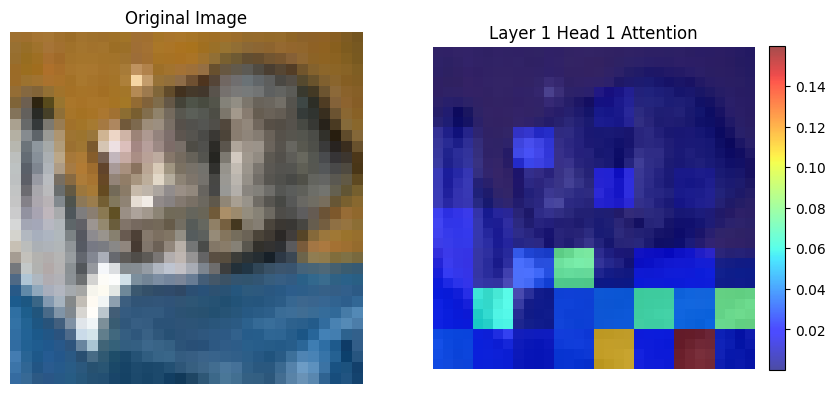

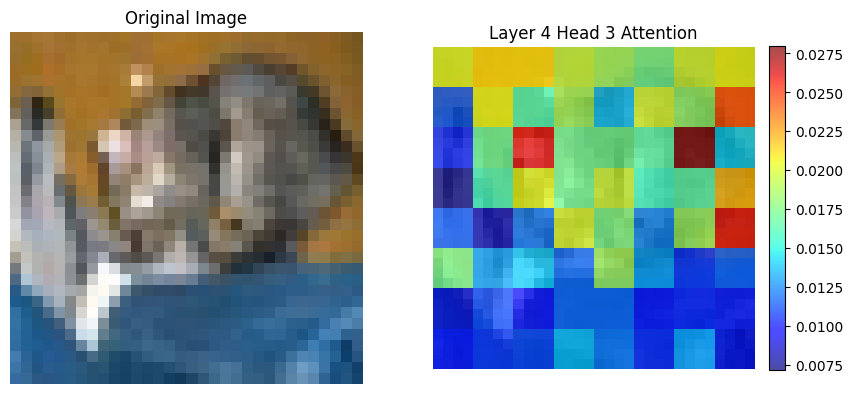

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_attention(model, img, layer_idx=0, head_idx=0, alpha=0.7):
    """
    Visualize attention maps for a given image and layer/head combination
    Args:
        model: Trained VisionTransformer instance
        img: Input image tensor [1, 3, 32, 32]
        layer_idx: Which transformer block to visualize (0-based)
        head_idx: Which attention head to visualize (0-based)
        alpha: Transparency for attention overlay
    """
    model.eval()  # Ensure model is in evaluation mode

    # Run forward pass and collect attention weights
    with torch.no_grad():
        _, attention_weights = model(img)

    # Process attention weights
    attn = attention_weights[layer_idx]  # [batch_size, num_heads, num_patches+1, num_patches+1]
    attn_map = attn[0, head_idx, 0, 1:]  # CLS token attention, exclude CLS itself

    # Reshape to patch grid
    patch_grid_size = int(np.sqrt(attn_map.size(0)))
    attn_map = attn_map.reshape(patch_grid_size, patch_grid_size).cpu().numpy()

    # Convert original image to numpy
    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * 0.5 + 0.5)  # unnormalize

    # Create overlay
    fig, ax = plt.subplots(1, 2, figsize=(10,5))
    ax[0].imshow(img_np)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    # Attention map visualization
    attn_resized = np.kron(attn_map, np.ones((PATCH_SIZE, PATCH_SIZE)))  # upsample to patch size
    ax[1].imshow(img_np)
    im = ax[1].imshow(attn_resized, cmap='jet', alpha=alpha)
    ax[1].set_title(f'Layer {layer_idx+1} Head {head_idx+1} Attention')
    ax[1].axis('off')

    plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    plt.show()

# Usage example with test image
sample_img, sample_label = next(iter(test_loader))
sample_img = sample_img[:1].to(device)  # Take first image of batch

# Visualize different layers/heads
visualize_attention(model, sample_img, layer_idx=0, head_idx=0)  # First layer, first head
visualize_attention(model, sample_img, layer_idx=3, head_idx=2)  # Last layer, third head
